# if we correct for experimental date (and NOT sex) as batch effect, 
- do we see two clusters? 

In [2]:
include_barmer =  False

import numpy as np
import matplotlib.pyplot as plt
import glob, os, sys
import scanpy as sc
import pandas as pd
import scvi 

print("Last run with scvi-tools version:", scvi.__version__)

Last run with scvi-tools version: 1.2.2.post2


In [3]:
adata_sc_orig = sc.read_h5ad("/home/shuonan.chen/scratch_shuonan//LC_scRNAseq/conversion_files_OLD/snRNAseq_LCNE.h5ad")
adata_sc_orig.obs['actualsex'] = adata_sc_orig.obs['sex'].str[0]  # take only first character 'M' or 'F'

In [4]:
if include_barmer:
    barseq_datapath = '/home/shuonan.chen/scratch_shuonan/scripts/LC_NE_dataintegration/BARseq/data/LCNE_barseq_counts_updated.csv'
    df = pd.read_csv(barseq_datapath)
    barseq_genes = df.iloc[:,0].tolist()
    barseq_genes = list(set(barseq_genes).intersection(adata_sc_orig.var_names))

filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)

var_names = adata_mer.var_names.intersection(adata_sc_orig.var_names)
adata_mer = adata_mer[:,var_names]  # 314 genes 

adata_sc_orig.raw = adata_sc_orig.copy()
sc.pp.highly_variable_genes(adata_sc_orig, n_top_genes=1500, flavor="seurat_v3", subset=True)
hvg_genes = adata_sc_orig.var_names[adata_sc_orig.var['highly_variable']].tolist()
genes_to_keep = list(set(hvg_genes))

if include_barmer:
    genes_to_keep = list(set(hvg_genes) | set(adata_mer.var_names.tolist()) | set(barseq_genes))
else:
    genes_to_keep = list(set(hvg_genes))

print(len(genes_to_keep))  # 1769 or 1500 for now!

    

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12040. The TBB threading layer is disabled.
  warnings.warn(problem)


1500


In [5]:
# save raw, and change the observations columns etc
raw_adata = adata_sc_orig.raw.to_adata()
adata_sc = raw_adata[:, genes_to_keep].copy()
totalcounts = np.sum(adata_sc.X, -1)
adata_sc.obs['totalcounts']=totalcounts
def batch_flag(x):
    # 1 for concatenated long strings, 0 for simple M/F
    return 1 if ';' in x else 2
adata_sc.obs['experimental_batch_id'] = adata_sc.obs['sex'].apply(batch_flag).astype(int)

# run scvi 

In [6]:
scvi.settings.seed = 1
scvi.model.SCVI.setup_anndata(adata_sc, batch_key='experimental_batch_id')
model = scvi.model.SCVI(adata_sc, n_layers=1, n_latent=4, gene_likelihood="zinb")
model.train()

[rank: 0] Seed set to 1
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /allen/aind/scratch/shuonan.chen/conda_envs/torch_on ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun

Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


In [7]:
SCVI_LATENT_KEY = "X_scVI"
adata_sc.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()

In [8]:
sc.pp.neighbors(adata_sc, use_rep=SCVI_LATENT_KEY, n_neighbors=15)
sc.tl.umap(adata_sc,random_state=210)
sc.tl.leiden(adata_sc,resolution = .5,random_state=210)

/scratch/fast/4150472/ipykernel_2938425/3066902326.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_sc,resolution = .5,random_state=210)


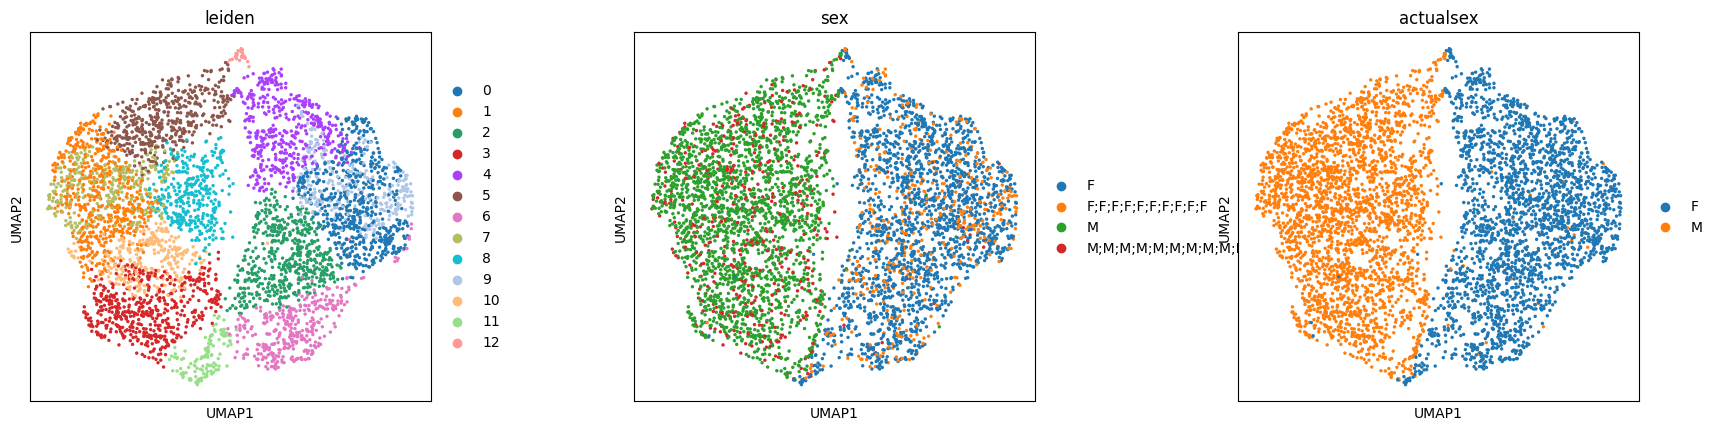

In [9]:
ax = sc.pl.umap(
    adata_sc,color=["leiden", "sex",'actualsex'],
    ncols=3,show = False)
for a in ax:
    a.set_aspect('equal')

# get the batch average normalized expression counts
- Denoised expression with batch “removed”

In [10]:
all_batches = model.adata_manager.get_state_registry("batch").categorical_mapping.tolist()
print(all_batches)

[1, 2]


In [11]:
X_hat_avg = model.get_normalized_expression(
    adata=adata_sc,
    transform_batch=all_batches,    
    library_size= 1, # we wont change this to 1e+6 here for now
    return_numpy=False
)  
import anndata
adata_sc_BN = anndata.AnnData(X_hat_avg.copy())
adata_sc_BN.obs = adata_sc.obs.copy()
adata_sc_BN.obsm = adata_sc.obsm.copy()
adata_sc_BN.var = adata_sc.var.copy()

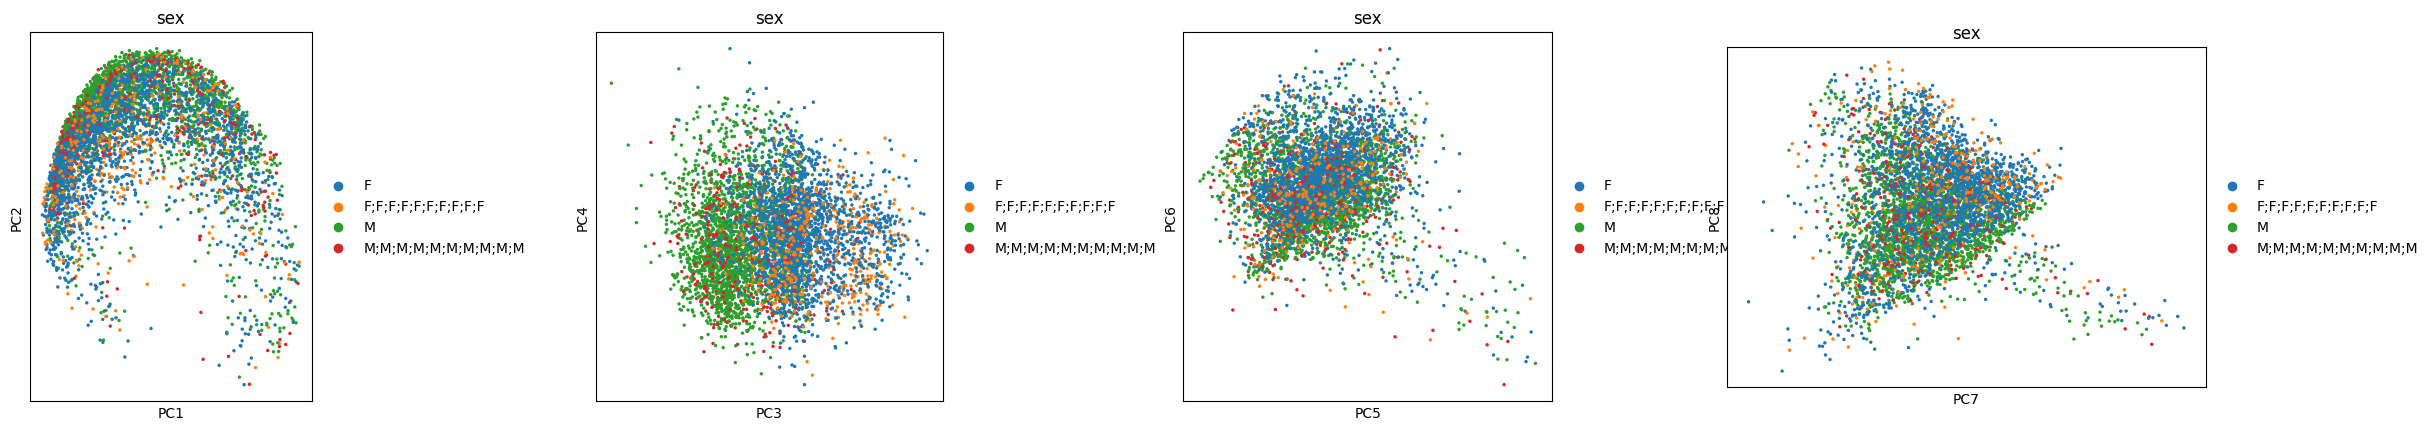

In [14]:
# standardize teh X for each genes
adata_sc_BN.X -= np.mean(adata_sc_BN.X, 0)
std_gene = np.std(adata_sc_BN.X, 0)
adata_sc_BN.X /= std_gene
sc.tl.pca(adata_sc_BN)
ax = sc.pl.pca(adata_sc_BN, dimensions=((0, 1), (2, 3), (4, 5), (6, 7)), show=False, color='sex')
for a in ax: a.set_aspect('equal')
plt.show()


In [1]:
ax = sc.pl.pca(adata_sc_BN, dimensions=((0, 1), (2, 3), (4, 5), (6, 7)), show=False, color='actualsex')
for a in ax: a.set_aspect('equal')
plt.show()

NameError: name 'sc' is not defined

# DONOT save this for now
